In [21]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send
import operator
from dotenv import load_dotenv
import os

In [22]:
os.environ['LANGCHAIN_PROJECT'] = 'BLOG_WRITING_AGENT_CREATION'

In [23]:
load_dotenv()


llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [24]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )

In [25]:
class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]

In [26]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: the results from workers get concatenated automatically
    sections : Annotated[list[str], operator.add]

    final: str

In [27]:
planner = llm.with_structured_output(Plan)

In [28]:
def orchestrator(state: State) -> State:
    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    return {
        'plan': plan
    }

In [29]:
def fanout(state: State):
    """
    DYNAMIC FAN-OUT (Map-Reduce) ROUTER
    ====================================
    WHAT THIS DOES:
    - Fanning out means splitting a single workflow execution into multiple 
      parallel tasks that run concurrently.
      
    WHY WE USE IT HERE:
    - Instead of generating section content one task at a time (sequentially), 
      we iterate over all tasks in `state['plan'].tasks` and spawn a dedicated 
      'worker' node for each task simultaneously. This speeds up total runtime.

    WHAT `Send('worker', payload)` DOES:
    - `Send` is LangGraph's primitive for dynamic parallel execution.
    - Argument 1 ('worker'): Specifies the target destination node to run.
    - Argument 2 ({...}): The isolated dictionary (payload) sent into that worker's 
      individual state. Each parallel worker receives its own specific task data.
    """
    return [
        Send('worker', {
            'plan': state['plan'],
            'task': task,
            'topic': state['topic'],
        })
        for task in state['plan'].tasks
    ]

In [30]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = llm.invoke(
        [
            SystemMessage(
    content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [31]:
import re
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- 1. Sanitize the title for Windows filenames ----
    # Keep only alphanumeric characters and spaces
    clean_title = re.sub(r'[^\w\s-]', '', title).strip()
    # Replace spaces with underscores
    filename = clean_title.lower().replace(" ", "_") + ".md"

    # ---- 2. Save to file ----
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    print(f"Successfully saved blog to: {output_path.resolve()}")

    return {"final": final_md}

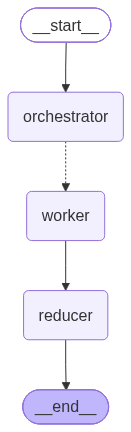

In [32]:
builder = StateGraph(State)

builder.add_node('orchestrator', orchestrator)
builder.add_node('worker', worker)
builder.add_node('reducer', reducer)


builder.add_edge(START, 'orchestrator')
builder.add_conditional_edges('orchestrator', fanout, ['worker'])
builder.add_edge('worker', 'reducer')
builder.add_edge('reducer', END)

graph = builder.compile()

graph

In [33]:
graph.invoke(
    {
        'topic': 'Write a blog on Self Attention'
    }
)



Successfully saved blog to: D:\Summer-2026\llm-engineering-lab\Practice Codes\Week 3\Day 4\Blog Writing Agent\demystifying_selfattention_from_theory_to_productionready_code.md


{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Demystifying Self‑Attention: From Theory to Production‑Ready Code', audience='software developers familiar with machine learning', tone='technical, actionable, and developer‑focused', tasks=[Task(id=1, title='Intuition: Queries, Keys, and Values in Plain Language', goal='Frame self‑attention as the solution to long‑range dependency and parallelism limitations in sequence models.', bullets=['Define the scaling problem in sequence models that motivates self‑attention (e.g., O(N²) vs. recurrent bottlenecks).', 'Show a simple data‑flow diagram that contrasts RNN, CNN, and self‑attention pipelines.', 'State the concrete learning objective: after this section the reader can articulate why self‑attention replaces recurrence in modern NLP.'], target_words=210, section_type='intro'), Task(id=2, title='Intuition: Queries, Keys, and Values in Plain Language', goal='Enable readers to visualize the self‑attention mechanism withou